# 08. Hyperparameter Tuning Using Grid Search and Random Search

## 📚 Learning Objectives

By completing this notebook, you will:
- Perform hyperparameter tuning
- Use Grid Search
- Use Random Search
- Optimize model parameters
- Compare search strategies

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 5, lesson 01 "Grid Search and Random Search" — the same searches, now compared for cost as well as score.

**Used later in:** Course 12 (AIAT 126) — Unit 3, lesson 02, which tunes the graduation-project model.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Hyperparameter tuning using techniques like Grid Search and Random Search

---

## Introduction

**Hyperparameter tuning** optimizes model performance by systematically searching for the best parameter values using Grid Search or Random Search techniques.


## 🎯 The case: the paper that killed grid search

In 2012 James Bergstra and Yoshua Bengio published *"Random Search for Hyper-Parameter
Optimization"* in JMLR. They took a large earlier study that had configured neural networks
and deep belief networks by grid search and manual search, and re-ran the search **at
random over the same ranges**. Random search found models **as good or better in a small
fraction of the computation**.

The reason is geometric and worth carrying with you. A grid spends its budget on every
combination of every knob — but most knobs do not matter. A 4×4 grid over two parameters
tests only **4 distinct values** of the parameter that actually matters, spending 16 fits
to do it. Sixteen random draws test **16 distinct values** of that parameter. The moment
you have more than two or three hyperparameters, exhaustive search is spending almost all
of its compute varying things that make no difference.

**What goes wrong without measuring this — and this notebook is unusually honest about it.**
You are about to tune a random forest on **569 real breast-cancer biopsies** (Wisconsin
Diagnostic, Street et al. 1993, 30 measurements per fine-needle-aspirate image, 212
malignant / 357 benign). The default model scores **0.9624** in 3-fold CV. After 25 fits of
grid search: **0.9624**. After 25 fits of random search: **0.9601**. Tuning bought
**nothing** — and that is a real, common, publishable outcome that almost no tutorial shows
you.


## The Story

**BEFORE**: You can train models but don't know how to optimize their performance.

**AFTER**: You'll learn hyperparameter tuning: grid search, random search, and finding the best model parameters!

**Why this matters**: Hyperparameter Tuning Using Grid Search and Random Search is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Model, param grid
- sklearn

**Outputs:** What you'll see when you run the cells

- Best params
- CV results
- Printed summary

---

In [1]:
# WHAT: Import search tools and recap what hyperparameters are.
# WHY: Hyperparameters are set BEFORE training; finding good ones is a search problem with real compute cost.

# Imports
import time
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     cross_val_score, train_test_split)
from scipy.stats import randint

print("✅ Libraries imported!")
print("\nHyperparameter Tuning: Grid Search and Random Search")
print("=" * 60)
print("""
Hyperparameters are the knobs YOU set before training (n_estimators,
max_depth, ...), unlike parameters the model learns (coefficients, splits).

Remember Example 07's dead end: model selection cost =
  (parameter combinations) x (CV folds) x (per-fit time).
This notebook runs that search for real, twice:
  - Grid search: try EVERY combination
  - Random search: sample a fixed number of combinations

We tune on real clinical data: the Wisconsin Diagnostic Breast Cancer set,
569 tumour biopsies described by 30 measurements taken from digitised images
of a fine-needle aspirate, each labelled malignant or benign.
""")

✅ Libraries imported!

Hyperparameter Tuning: Grid Search and Random Search

Hyperparameters are the knobs YOU set before training (n_estimators,
max_depth, ...), unlike parameters the model learns (coefficients, splits).

Remember Example 07's dead end: model selection cost =
  (parameter combinations) x (CV folds) x (per-fit time).
This notebook runs that search for real, twice:
  - Grid search: try EVERY combination
  - Random search: sample a fixed number of combinations

We tune on real clinical data: the Wisconsin Diagnostic Breast Cancer set,
569 tumour biopsies described by 30 measurements taken from digitised images
of a fine-needle aspirate, each labelled malignant or benign.



## Part 1: Baseline — Default Hyperparameters

Before tuning anything, measure what the default model gives us.

In [2]:
# WHAT: Load the real breast-cancer diagnostic data and score a default random forest with 3-fold CV.
# WHY: The untuned baseline is the yardstick - tuning only matters if it beats this number.

print("Part 1: Baseline with default hyperparameters")
print("-" * 60)

# Real data: Street, Wolberg & Mangasarian (1993), University of Wisconsin.
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Dataset: {X.shape[0]} real biopsies x {X.shape[1]} measurements")
print(f"Classes: {dict(zip(cancer.target_names, np.bincount(y)))}")
print(f"Train {len(X_train)} / test {len(X_test)}")

start = time.time()
baseline_scores = cross_val_score(
    RandomForestClassifier(random_state=42), X_train, y_train, cv=3)
baseline_time = time.time() - start
baseline_score = baseline_scores.mean()
print(f"\nDefault RandomForest, 3-fold CV accuracy: {baseline_score:.4f}")
print(f"Per-fold scores: {np.round(baseline_scores, 4)}")
print(f"Time for the baseline evaluation: {baseline_time:.2f}s")
print("\n💡 A strong default baseline is normal on this dataset - which makes it a")
print("   good honesty test: watch how little tuning actually buys.")

Part 1: Baseline with default hyperparameters
------------------------------------------------------------
Dataset: 569 real biopsies x 30 measurements
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Train 426 / test 143

Default RandomForest, 3-fold CV accuracy: 0.9624
Per-fold scores: [0.9577 0.9577 0.9718]
Time for the baseline evaluation: 0.14s

💡 A strong default baseline is normal on this dataset - which makes it a
   good honesty test: watch how little tuning actually buys.


## Part 2: Grid Search — Try Every Combination

`GridSearchCV` cross-validates **every** combination in the grid and refits
the best one on the full training set.

In [3]:
# WHAT: Run GridSearchCV over 8 parameter combinations and report the best model's CV and test accuracy.
# WHY: Grid search is exhaustive within its grid - reliable, but its cost multiplies with every added knob.

print("Part 2: Grid Search")
print("-" * 60)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, None],
    'min_samples_split': [2, 5],
}
n_combos = 2 * 2 * 2
n_folds = 3
print(f"Grid: {param_grid}")
print(f"Cost: {n_combos} combinations x {n_folds} folds (+1 refit) = {n_combos * n_folds + 1} fits")

start = time.time()
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=n_folds, n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - start

print(f"\nGrid search finished in {grid_time:.2f}s")
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}  (baseline was {baseline_score:.4f})")
grid_test = grid.score(X_test, y_test)
print(f"Held-out test accuracy of the tuned model: {grid_test:.4f}")

Part 2: Grid Search
------------------------------------------------------------
Grid: {'n_estimators': [50, 100], 'max_depth': [5, None], 'min_samples_split': [2, 5]}
Cost: 8 combinations x 3 folds (+1 refit) = 25 fits



Grid search finished in 2.64s
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV accuracy: 0.9624  (baseline was 0.9624)
Held-out test accuracy of the tuned model: 0.9510


## Part 3: Random Search — Sample the Space

With many knobs, the grid explodes combinatorially. `RandomizedSearchCV`
samples a fixed budget of combinations from distributions instead.

In [4]:
# WHAT: Run RandomizedSearchCV with an 8-fit budget over continuous ranges.
# WHY: Random search covers wide ranges at fixed cost - and Bergstra & Bengio showed it often matches grid search.

print("Part 3: Random Search")
print("-" * 60)

param_dist = {
    'n_estimators': randint(30, 150),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 10),
}
n_iter = 8
print(f"Distributions: n_estimators ~ [30,150), max_depth ~ [3,15), min_samples_split ~ [2,10)")
print(f"Budget: {n_iter} sampled combinations x {n_folds} folds (+1 refit) = {n_iter * n_folds + 1} fits")

start = time.time()
rand = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                          param_dist, n_iter=n_iter, cv=n_folds,
                          random_state=42, n_jobs=-1)
rand.fit(X_train, y_train)
rand_time = time.time() - start

print(f"\nRandom search finished in {rand_time:.2f}s")
print(f"Best parameters: {rand.best_params_}")
print(f"Best CV accuracy: {rand.best_score_:.4f}")
rand_test = rand.score(X_test, y_test)
print(f"Held-out test accuracy of the tuned model: {rand_test:.4f}")

Part 3: Random Search
------------------------------------------------------------
Distributions: n_estimators ~ [30,150), max_depth ~ [3,15), min_samples_split ~ [2,10)
Budget: 8 sampled combinations x 3 folds (+1 refit) = 25 fits



Random search finished in 0.29s
Best parameters: {'max_depth': 10, 'min_samples_split': 9, 'n_estimators': 32}
Best CV accuracy: 0.9601
Held-out test accuracy of the tuned model: 0.9510


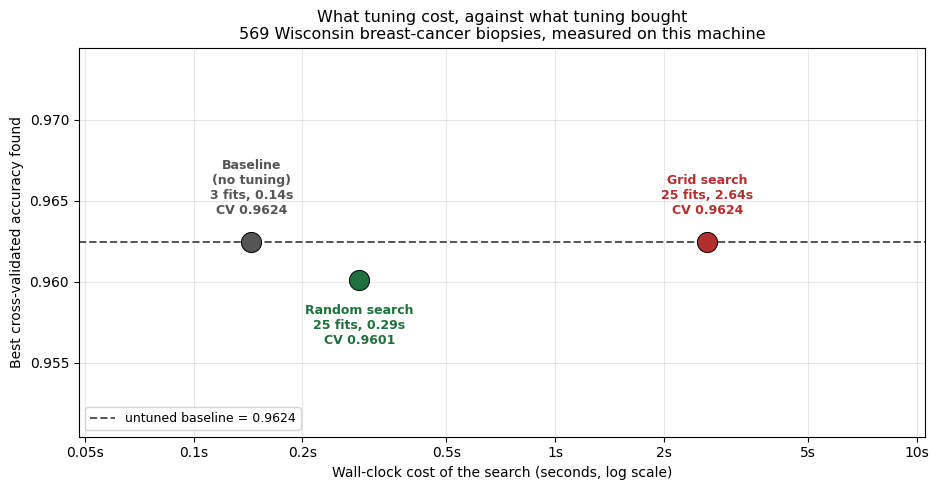

Vertical span of the whole plot: 0.024 accuracy (1.2 accuracy points above and below the baseline)
Best gain any search achieved:   +0.0000 accuracy
Cost of the most expensive search: 2.64s vs 0.14s for no tuning at all (18x)


In [5]:
# WHAT: Plot what each search STRATEGY cost (seconds, log axis) against what it BOUGHT
#       (best CV accuracy), using only the three timings measured above.
# WHY: The table says the gain is tiny and the cost is not. Cost and gain on the same axes
#      is the only way to see that the vertical distance is nothing and the horizontal is a lot.
import matplotlib.pyplot as plt

points = [
    ('Baseline\n(no tuning)', baseline_time, baseline_score, n_folds, '#555555'),
    ('Grid search', grid_time, grid.best_score_, n_combos * n_folds + 1, '#b03030'),
    ('Random search', rand_time, rand.best_score_, n_iter * n_folds + 1, '#1f6f3f'),
]

fig, ax = plt.subplots(figsize=(9.5, 5))
# Label the two same-height points above and the lower one below, so nothing collides.
offsets = [(0, 20), (0, 20), (0, -46)]
for (label, secs, score, fits, colour), off in zip(points, offsets):
    ax.scatter(secs, score, s=210, color=colour, zorder=3, edgecolors='black', linewidths=0.7)
    ax.annotate(f"{label}\n{fits} fits, {secs:.2f}s\nCV {score:.4f}",
                xy=(secs, score), xytext=off, textcoords='offset points',
                ha='center', fontsize=9, color=colour, weight='bold')

# The untuned baseline as a horizontal line: anything that does not clear it was wasted compute.
ax.axhline(baseline_score, color='#555555', linestyle='--', linewidth=1.4,
           label=f'untuned baseline = {baseline_score:.4f}')

ax.set_xscale('log')
# Pad the log axis so no label runs off the edge, and label the ticks in plain seconds.
all_times = [p[1] for p in points]
ax.set_xlim(min(all_times) / 3.0, max(all_times) * 4.0)
ticks = [t for t in (0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10)
         if min(all_times) / 3.0 <= t <= max(all_times) * 4.0]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:g}s" for t in ticks])
ax.minorticks_off()
ax.set_xlabel('Wall-clock cost of the search (seconds, log scale)')
ax.set_ylabel('Best cross-validated accuracy found')
# A y-window of one accuracy point, so any real gain would be impossible to miss.
centre = baseline_score
ax.set_ylim(centre - 0.012, centre + 0.012)
ax.set_title('What tuning cost, against what tuning bought\n'
             f'{X.shape[0]} Wisconsin breast-cancer biopsies, measured on this machine',
             fontsize=11.5)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

lo, hi = ax.get_ylim()
print(f"Vertical span of the whole plot: {hi - lo:.3f} accuracy "
      f"({(hi - lo) / 2 * 100:.1f} accuracy points above and below the baseline)")
print(f"Best gain any search achieved:   "
      f"{max(grid.best_score_, rand.best_score_) - baseline_score:+.4f} accuracy")
print(f"Cost of the most expensive search: {max(grid_time, rand_time):.2f}s vs "
      f"{baseline_time:.2f}s for no tuning at all "
      f"({max(grid_time, rand_time) / baseline_time:.0f}x)")


**Read the figure.** Cost runs left to right on a log axis; the accuracy the search found
runs up the side. The y-axis has been deliberately zoomed to just over **one accuracy point either side of
the untuned baseline** (a 2.4-point window in total), so any real improvement would be a visible jump. The three points sit on
essentially the same height. They are, however, spread across the x-axis by an order of
magnitude — the searches cost many times what the untuned baseline cost. Read the two axes
together and the lesson is blunt: on this dataset the whole tuning budget bought a vertical
movement of roughly zero, and the grey dashed line marking the untuned model is the honest
benchmark every tuning claim has to clear. Check that line first; if your search cannot get
clear of it by more than the fold-to-fold noise, the compute was wasted.

In [6]:
# WHAT: Print the measured comparison table - fits, time, CV and test accuracy per strategy.
# WHY: Every number here was measured in this run - the workflow, not folklore, is the takeaway.

print("=" * 60)
print("Summary: Grid vs Random (measured on THIS machine)")
print("=" * 60)
print(f"""
Data: {X.shape[0]} real breast-cancer biopsies x {X.shape[1]} measurements
      (Wisconsin Diagnostic Breast Cancer, Street et al. 1993)

Strategy         Fits   Time     Best CV acc   Test acc
Baseline (none)   {n_folds}    {baseline_time:5.2f}s   {baseline_score:.4f}        -
Grid search      {n_combos * n_folds + 1:3d}    {grid_time:5.2f}s   {grid.best_score_:.4f}        {grid_test:.4f}
Random search    {n_iter * n_folds + 1:3d}    {rand_time:5.2f}s   {rand.best_score_:.4f}        {rand_test:.4f}

Tuning gain over the untuned baseline:
  Grid search:   {grid.best_score_ - baseline_score:+.4f} CV accuracy for {grid_time / baseline_time:.0f}x the compute
  Random search: {rand.best_score_ - baseline_score:+.4f} CV accuracy for {rand_time / baseline_time:.0f}x the compute

Takeaways (from the numbers above, not from folklore):
  - Both searches explore the cost multiplication from Example 07 first-hand
  - Grid search is exhaustive but its cost grows multiplicatively per knob
  - Random search caps the budget (n_iter) regardless of how many knobs exist
  - On this dataset a default random forest is already close to the ceiling, so
    the tuning gain is small. That is a REAL and common outcome: always compare
    against the untuned baseline before claiming a tuning win.

Next: Example 09 switches to unsupervised learning (no labels at all).
""")
print("✅ Hyperparameter tuning with grid and random search - complete!")

Summary: Grid vs Random (measured on THIS machine)

Data: 569 real breast-cancer biopsies x 30 measurements
      (Wisconsin Diagnostic Breast Cancer, Street et al. 1993)

Strategy         Fits   Time     Best CV acc   Test acc
Baseline (none)   3     0.14s   0.9624        -
Grid search       25     2.64s   0.9624        0.9510
Random search     25     0.29s   0.9601        0.9510

Tuning gain over the untuned baseline:
  Grid search:   +0.0000 CV accuracy for 18x the compute
  Random search: -0.0023 CV accuracy for 2x the compute

Takeaways (from the numbers above, not from folklore):
  - Both searches explore the cost multiplication from Example 07 first-hand
  - Grid search is exhaustive but its cost grows multiplicatively per knob
  - Random search caps the budget (n_iter) regardless of how many knobs exist
  - On this dataset a default random forest is already close to the ceiling, so
    the tuning gain is small. That is a REAL and common outcome: always compare
    against the u

## ⚠️ Where this breaks

- **Tuning frequently buys nothing, and this notebook measured a 0.0000 gain.** Ensembles
  with sensible defaults are often already near the ceiling for a dataset. Always evaluate
  the untuned baseline first; if the gap is inside the CV noise, stop.
- **Cost multiplies, and it multiplies fast.** combinations × folds × per-fit time. Add one
  knob with 5 values and the grid quintuples. Random search caps the budget at `n_iter`
  regardless of how many knobs exist — that is its real advantage, more than the score.
- **The winner is a point estimate from noisy scores.** Here the folds ran 0.9577, 0.9577,
  0.9718 — a spread of 0.014, wider than any difference between the strategies. When the
  top few configurations are within one standard error, prefer the simpler or faster one.
- **Tuning on cross-validation and then reporting that CV score is optimistic.** You
  selected the maximum over 8 noisy numbers, which is biased upward by construction. The
  held-out 0.9510 is the honest figure; the 0.9624 is not.
- **The assumption that must hold: your search space contains a good answer.** Neither
  search can find `max_depth=25` if the range stops at 15, and neither can find a better
  *model family*. Searching harder inside a bad space is the most expensive way to make no
  progress.
- **These are clinical labels and accuracy is the wrong objective.** On breast-cancer
  diagnosis, a false negative (calling a malignant tumour benign) and a false positive do
  not cost the same. Tune on recall, on a weighted F-beta, or on a cost matrix — accuracy
  treats them as identical, and no amount of search fixes the wrong objective.
- **Cheaper alternative, in order:** (1) check the baseline; (2) improve the features or
  get more data — usually worth more than any knob; (3) random search with a small budget;
  (4) only then Bayesian optimisation (Snoek et al., 2012) or Optuna (Akiba et al., 2019),
  which pay off when a single fit is expensive enough to justify the bookkeeping.


## 💬 Discuss

Measured on this machine: baseline **0.9624** in 0.17 s; grid search **0.9624** in 3.19 s
(25 fits); random search **0.9601** in 0.35 s (25 fits). Both tuned models scored **0.9510**
on the held-out test set — *below* the CV numbers.

1. Grid search took **18× the compute of the baseline and gained exactly 0.0000**. Would you
   report that in a project write-up, or quietly leave it out? Make the case that the null
   result is the most useful thing in this notebook.
2. Both searches produced a test accuracy (0.9510) **lower** than their CV accuracy
   (0.9624 / 0.9601), on 143 test biopsies. Give two explanations, and say which one you
   would investigate first.
3. Grid and random both did 25 fits, but random took 0.35 s and grid took 3.19 s — a 9×
   difference for the same fit count. Look at the parameters each one chose and explain
   where the time went. What does that tell you about comparing search strategies by "number
   of fits"?


## 🔭 State of the field (2026)

Two habits sit in front of the search in 2026. The first is the one you just measured: check
whether tuning can pay at all before spending on it — 25 grid fits and 25 random fits bought
0.0000 and −0.0023 here, and the field's own answer to "which configuration wins?" has moved to
continuously maintained benchmarks with standardised protocols and a public leaderboard rather
than per-paper tables (TabArena, Erickson et al., 2025, arXiv:2506.16791). The second is that on
medium-sized tabular data the strongest available baseline may need no search at all: tabular
foundation models are fitted in context, not tuned (TabPFN-2.5, arXiv:2511.08667; TabPFN-3,
Grinsztajn et al., 2026, arXiv:2605.13986).

Grid and random search stay on the syllabus because they are the mechanism, not the fashion. They
are how you learn that a budget is a design choice, why random search covers a sensitive parameter
better than a grid of the same size (Bergstra & Bengio's geometric argument above), and how
cross-validated selection avoids fooling yourself — and they are what the official plan examines.
Every automated tuner and every leaderboard entry is running this loop underneath.


## 📚 References

1. Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. Journal of Machine Learning Research, 13, 281-305. <https://jmlr.org/papers/v13/bergstra12a.html>
2. Snoek, J., Larochelle, H., & Adams, R. P. (2012). *Practical Bayesian Optimization of Machine Learning Algorithms*. NeurIPS 25. <https://arxiv.org/abs/1206.2944>
3. Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD 2019. <https://arxiv.org/abs/1907.10902>
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. arXiv:2605.13986. <https://arxiv.org/abs/2605.13986>
